# Uncertainty sets

The view priors so far ([Black–Litterman](05_Black_Litterman.md),
[Entropy Pooling](07_Entropy_Pooling.md), [Opinion Pooling](08_Opinion_Pooling.md)) change
*what* the moments are. **Robust optimisation** takes the opposite stance: it accepts that the
estimated moments are *wrong by some amount* and optimises against the worst case within an
**uncertainty set** around them. Rather than trusting a single point estimate of the
covariance (or mean), you bound a region the true value plausibly lies in and minimise the
worst-case risk (or maximise the worst-case return) over that region. The result is an
allocation that is stable to estimation error by construction.

`PortfolioOptimisers` builds uncertainty sets with an estimator such as
`NormalUncertaintySet` and an algorithm — `BoxUncertaintySetAlgorithm` (a
per-entry interval box) or `EllipsoidalUncertaintySetAlgorithm` (a joint ellipsoid).
The helper `sigma_ucs` produces a covariance set and `mu_ucs` a mean set; the
covariance set parametrises a robust risk measure like `UncertaintySetVariance`, while
the mean set plugs into `ArithmeticReturn` to give a worst-case expected return. This
page is a deep dive across both: covariance robustness, the confidence level that sizes the
set, and worst-case-mean robust returns.

> **When to reach for this**
>
> Reach for uncertainty sets when you care less about a forecast and more about *robustness*
> to the noise in the moments — short windows, unstable covariances, regime risk. A box set
> is simple and conservative (it bounds each entry independently); an ellipsoidal set captures
> the joint geometry. Which one diversifies depends on *what* you make robust: see sections 4
> and 5 below. If you have actual views about where the moments are headed, reach for the view
> priors instead — or combine both, since a robust risk measure composes with any prior.

In [1]:
using PortfolioOptimisers, PrettyTables, StableRNGs

resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

LowOrderPrior
        X ┼ 252×20 Matrix{Float64}
       mu ┼ 20-element Vector{Float64}
    sigma ┼ 20×20 Matrix{Float64}
     chol ┼ nothing
        w ┼ nothing
      ens ┼ nothing
      kld ┼ nothing
       ow ┼ nothing
       rr ┼ nothing
     f_mu ┼ nothing
  f_sigma ┼ nothing
      f_w ┴ nothing


## 2. Building covariance uncertainty sets

We construct two covariance uncertainty sets from a `NormalUncertaintySet` — one box,
one ellipsoidal. The set is estimated by resampling, so we fix an RNG for reproducibility.

In [3]:
ucs_box = sigma_ucs(NormalUncertaintySet(; pe = EmpiricalPrior(), rng = StableRNG(1),
                                         alg = BoxUncertaintySetAlgorithm()), rd.X)
ucs_ell = sigma_ucs(NormalUncertaintySet(; pe = EmpiricalPrior(), rng = StableRNG(1),
                                         alg = EllipsoidalUncertaintySetAlgorithm()), rd.X)

EllipsoidalUncertaintySet
  sigma ┼ 400×400 LinearAlgebra.Diagonal{Float64, Vector{Float64}}
      k ┼ Float64: 55.93332343078506
  class ┴ SigmaEllipsoidalUncertaintySet()


## 3. The confidence level `q` sizes the set

`NormalUncertaintySet` takes a confidence level `q` (default `0.05`). It controls *how big* the
uncertainty set is: a **smaller `q` is more demanding** and yields a **larger, more
conservative** set, because you are insuring against a more extreme worst case. For a box set
this widens every per-entry interval; for an ellipsoidal set it inflates the radius. We sweep
`q` and measure the total width of the box (the sum of interval lengths) to watch the set grow
as `q` shrinks.

In [4]:
qs = [0.01, 0.05, 0.10, 0.20]
box_widths = [let u = sigma_ucs(NormalUncertaintySet(; rng = StableRNG(1), q = q,
                                                     alg = BoxUncertaintySetAlgorithm()),
                                rd.X)
                  sum(abs, u.ub .- u.lb)
              end
              for q in qs]

pretty_table(DataFrame(; q = qs, Symbol("box total width") => box_widths);
             title = "Smaller q → wider (more conservative) uncertainty set")

Smaller q → wider (more conservative) uncertainty set
┌─────────┬─────────────────┐
│       q │ box total width │
│ Float64 │         Float64 │
├─────────┼─────────────────┤
│    0.01 │       0.0576656 │
│    0.05 │       0.0440054 │
│     0.1 │       0.0370207 │
│     0.2 │        0.028841 │
└─────────┴─────────────────┘


## 4. Robust vs nominal minimum-variance

`UncertaintySetVariance` is the robust counterpart of `Variance`: it minimises
the worst-case variance over the uncertainty set rather than the point estimate. We compare a
nominal minimum-variance portfolio against the box- and ellipsoid-robust versions.

In [5]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

res_nom = optimise(MeanRisk(; r = Variance(), obj = MinimumRisk(),
                            opt = JuMPOptimiser(; pe = pr, slv = slv)))
res_box = optimise(MeanRisk(; r = UncertaintySetVariance(; ucs = ucs_box),
                            obj = MinimumRisk(), opt = JuMPOptimiser(; pe = pr, slv = slv)))
res_ell = optimise(MeanRisk(; r = UncertaintySetVariance(; ucs = ucs_ell),
                            obj = MinimumRisk(), opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

The robust portfolios hedge against covariance estimation error. For *covariance* robustness the
ellipsoidal set — which captures the joint geometry of the estimation error rather than bounding
each entry on its own — typically produces the more diversified, less concentrated allocation.

In [6]:
pretty_table(DataFrame(["Assets" => rd.nx, "Nominal" => res_nom.w,
                        "Box-robust" => res_box.w, "Ellipsoid-robust" => res_ell.w]);
             formatters = [resfmt], title = "Minimum-variance weights: nominal vs robust")

     Minimum-variance weights: nominal vs robust
┌────────┬──────────┬────────────┬──────────────────┐
│ Assets │  Nominal │ Box-robust │ Ellipsoid-robust │
│ String │  Float64 │    Float64 │          Float64 │
├────────┼──────────┼────────────┼──────────────────┤
│   AAPL │    0.0 % │      0.0 % │          0.794 % │
│    AMD │    0.0 % │      0.0 % │            0.0 % │
│    BAC │    0.0 % │      0.0 % │          2.538 % │
│    BBY │    0.0 % │      0.0 % │          0.659 % │
│    CVX │  7.432 % │    7.168 % │          4.714 % │
│     GE │  0.806 % │      0.0 % │          2.512 % │
│     HD │    0.0 % │      0.0 % │          2.836 % │
│    JNJ │ 36.974 % │   41.083 % │         15.332 % │
│    JPM │  0.749 % │      0.0 % │          3.378 % │
│     KO │ 11.161 % │    14.02 % │          9.897 % │
│    LLY │    0.0 % │      0.0 % │          4.317 % │
│    MRK │ 17.467 % │    17.04 % │         11.961 % │
│   MSFT │    0.0 % │      0.0 % │          1.476 % │
│    PEP │  8.978 % │   10.924 % 

Nominal vs box- vs ellipsoid-robust minimum variance.

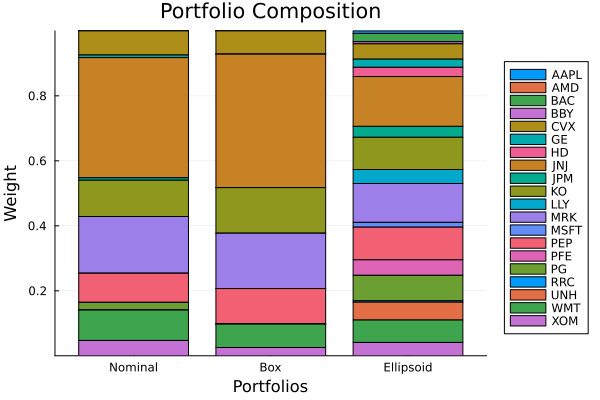

In [7]:
using StatsPlots, GraphRecipes
plot_stacked_bar_composition([res_nom, res_box, res_ell], rd;
                             xticks = (1:3, ["Nominal", "Box", "Ellipsoid"]))

## 5. Worst-case mean: robust expected returns

Robustness is not only about the covariance. A mean uncertainty set, built with `mu_ucs`,
plugs into `ArithmeticReturn` via its `ucs` keyword and makes the optimiser maximise the
**worst-case** expected return over the set instead of the point estimate. This guards a
return-seeking objective against the fact that sample means are extremely noisy over a single
year.

A wiring note worth knowing: pass `ArithmeticReturn` a **pre-built** mean set (the result of
`mu_ucs`), exactly as `UncertaintySetVariance` takes a pre-built `sigma_ucs` result. (Handing it
the *estimator* instead defers construction to solve time and requires the returns data to be
threaded through the optimiser.)

In [8]:
rf = 4.2 / 100 / 252

mu_box = mu_ucs(NormalUncertaintySet(; pe = EmpiricalPrior(), rng = StableRNG(1),
                                     alg = BoxUncertaintySetAlgorithm()), rd)
mu_ell = mu_ucs(NormalUncertaintySet(; pe = EmpiricalPrior(), rng = StableRNG(1),
                                     alg = EllipsoidalUncertaintySetAlgorithm()), rd)

ret_nom = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr, slv = slv)))
ret_box = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                ret = ArithmeticReturn(; ucs = mu_box))))
ret_ell = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                ret = ArithmeticReturn(; ucs = mu_ell))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

The geometry flips relative to the covariance case. With a **box** mean set every asset's mean is
pushed to its own lower bound independently, so the worst-case maximum-ratio portfolio piles into
whichever single name still has the best worst-case Sharpe — it *concentrates*. The **ellipsoidal**
mean set couples the assets through the joint estimation geometry, so no single name can be cheap
in isolation and the worst-case allocation spreads out toward a near-equal-weight portfolio. The
lesson: "box vs ellipsoid" does not map to "concentrated vs diversified" in the abstract — it
depends on whether you are making the *mean* or the *covariance* robust.

           Maximum-ratio weights: nominal vs worst-case mean
┌────────┬──────────┬─────────────────────┬───────────────────────────┐
│ Assets │  Nominal │ Box worst-case mean │ Ellipsoid worst-case mean │
│ String │  Float64 │             Float64 │                   Float64 │
├────────┼──────────┼─────────────────────┼───────────────────────────┤
│   AAPL │    0.0 % │             0.035 % │                   3.224 % │
│    AMD │    0.0 % │             0.016 % │                   1.412 % │
│    BAC │    0.0 % │              0.04 % │                   3.735 % │
│    BBY │    0.0 % │             0.039 % │                   2.374 % │
│    CVX │    0.0 % │             0.212 % │                   4.252 % │
│     GE │    0.0 % │             0.048 % │                   3.474 % │
│     HD │    0.0 % │             0.045 % │                   3.987 % │
│    JNJ │    0.0 % │             0.135 % │                    9.77 % │
│    JPM │    0.0 % │             0.053 % │                   4.345 % │
│  

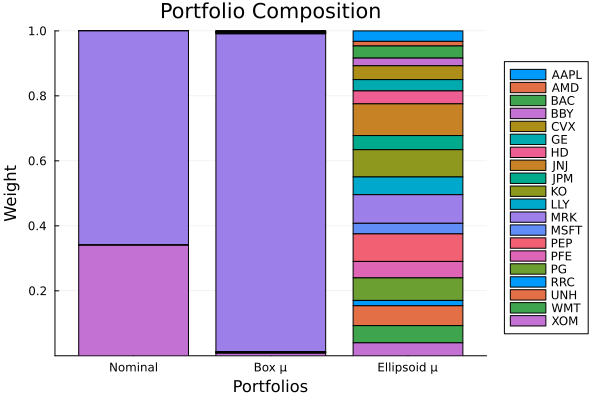

In [9]:
pretty_table(DataFrame(["Assets" => rd.nx, "Nominal" => ret_nom.w,
                        "Box worst-case mean" => ret_box.w,
                        "Ellipsoid worst-case mean" => ret_ell.w]); formatters = [resfmt],
             title = "Maximum-ratio weights: nominal vs worst-case mean")

plot_stacked_bar_composition([ret_nom, ret_box, ret_ell], rd;
                             xticks = (1:3, ["Nominal", "Box μ", "Ellipsoid μ"]))

## 6. Other set estimators: Delta and the ARCH bootstrap

`NormalUncertaintySet` resamples under a Gaussian assumption, but it is not the only
estimator. The simplest alternative is `DeltaUncertaintySet`: a fixed *fractional
perturbation* box around the point estimate, with no resampling at all. It is deterministic and
essentially free to build — the set size is a modelling choice rather than something learned
from the data. We build a covariance box with it and compare its total width against the Normal
box from section 2.

In [10]:
ucs_delta = sigma_ucs(DeltaUncertaintySet(), rd.X)

set_width(u) = sum(abs, u.ub .- u.lb)
pretty_table(DataFrame(; estimator = ["Delta (fixed)", "Normal (q=0.05)"],
                       Symbol("box total width") =>
                           [set_width(ucs_delta), set_width(ucs_box)]);
             title = "Delta is a tight, deterministic box")

 Delta is a tight, deterministic box
┌─────────────────┬─────────────────┐
│       estimator │ box total width │
│          String │         Float64 │
├─────────────────┼─────────────────┤
│   Delta (fixed) │       0.0131652 │
│ Normal (q=0.05) │       0.0440054 │
└─────────────────┴─────────────────┘


The Delta set is tighter than the Normal one here — a small fixed perturbation rather than a
resampled interval. It plugs into `UncertaintySetVariance` exactly like the Normal set,
so we solve a robust minimum-variance portfolio with it and compare against the Normal-box
version from section 4.

Minimum-variance weights: Delta vs Normal box
┌────────┬──────────────┬───────────────────┐
│ Assets │ Delta-robust │ Normal-box-robust │
│ String │      Float64 │           Float64 │
├────────┼──────────────┼───────────────────┤
│   AAPL │        0.0 % │             0.0 % │
│    AMD │        0.0 % │             0.0 % │
│    BAC │        0.0 % │             0.0 % │
│    BBY │        0.0 % │             0.0 % │
│    CVX │      7.411 % │           7.168 % │
│     GE │      0.823 % │             0.0 % │
│     HD │        0.0 % │             0.0 % │
│    JNJ │     36.964 % │          41.083 % │
│    JPM │      0.759 % │             0.0 % │
│     KO │     11.103 % │           14.02 % │
│    LLY │        0.0 % │             0.0 % │
│    MRK │     17.474 % │           17.04 % │
│   MSFT │        0.0 % │             0.0 % │
│    PEP │      8.976 % │          10.924 % │
│      ⋮ │            ⋮ │                 ⋮ │
└────────┴──────────────┴───────────────────┘
                               6 r

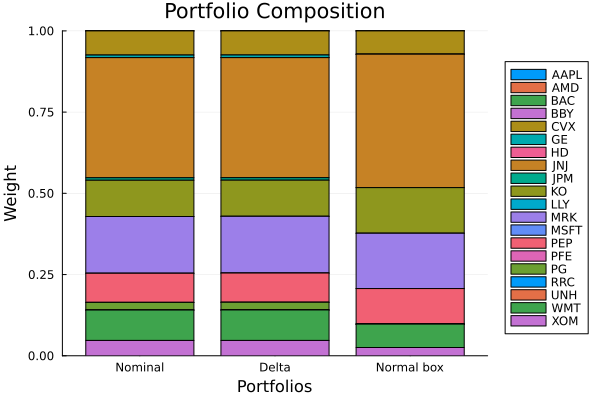

In [11]:
res_delta = optimise(MeanRisk(; r = UncertaintySetVariance(; ucs = ucs_delta),
                              obj = MinimumRisk(),
                              opt = JuMPOptimiser(; pe = pr, slv = slv)))

pretty_table(DataFrame(["Assets" => rd.nx, "Delta-robust" => res_delta.w,
                        "Normal-box-robust" => res_box.w]); formatters = [resfmt],
             title = "Minimum-variance weights: Delta vs Normal box")

plot_stacked_bar_composition([res_nom, res_delta, res_box], rd;
                             xticks = (1:3, ["Nominal", "Delta", "Normal box"]))

> **Data-driven sets: the ARCH bootstrap**
>
> For a set that reflects the data's *own* tail thickness and serial dependence rather than a
> Gaussian or a fixed delta, use `ARCHUncertaintySet`. It resamples the returns with a
> block bootstrap — `StationaryBootstrap`, `MovingBootstrap`, or
> `CircularBootstrap` — and is built the same way:
> ```julia
> ucs_arch = sigma_ucs(ARCHUncertaintySet(; alg = BoxUncertaintySetAlgorithm(),
>                                         bootstrap = StationaryBootstrap(), n_sim = 100,
>                                         seed = 1), rd.X)
> ```
> The resulting set is wider than the Gaussian one (it captures fat tails and autocorrelation
> that the Normal estimator misses) and drops into `UncertaintySetVariance` identically. It is
> the most data-driven of the three estimators and also the most expensive — it runs `n_sim`
> bootstrap resamples — so it is described here rather than executed in this page.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*